# 🔍 Module 10 · Exploratory Data Analysis (EDA)
### Course: Python from Scratch for Data Analysis

**Prerequisites:** Modules 1–9

### What you will learn today
1. Outlier detection and treatment (IQR method + Z-score)
2. Correlation analysis and interpretation
3. Formulating and answering analytical questions
4. Full EDA walkthrough on a synthetic HR dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 80  # 80 employees.

departments = ["Engineering", "Marketing", "HR", "Sales", "Finance"]
cities = ["Bogotá", "Medellín", "Cali", "Barranquilla", "Bucaramanga"]

names_first = ["Valentina", "Santiago", "Camila", "Andrés", "Isabella", "Daniel", "Sofía",
               "Miguel", "Mariana", "Julián", "Laura", "Carlos", "Ana", "Felipe", "Paola",
               "Esteban", "Natalia", "Ricardo", "Alejandra", "Sebastián", "Daniela", "Tomás",
               "Gabriela", "Mateo", "Luciana", "David", "Sara", "Nicolás", "Manuela", "Diego"]
names_last = ["Torres", "Gómez", "Restrepo", "Martínez", "Vargas", "Herrera", "López",
              "Castro", "Díaz", "Pérez", "Suárez", "Rodríguez", "Moreno", "Jiménez", "Ramírez",
              "Ospina", "Cárdenas", "Mora", "Ríos", "Salazar", "Guerrero", "Pardo", "Ruiz", "Cruz", "Molina"]

np.random.shuffle(names_first)

employees = pd.DataFrame({
    "name": [f"{names_first[i % len(names_first)]} {names_last[i % len(names_last)]}" for i in range(n)],
    "department": np.random.choice(departments, n, p=[0.30, 0.20, 0.15, 0.25, 0.10]),
    "city": np.random.choice(cities, n, p=[0.40, 0.25, 0.15, 0.12, 0.08]),
    "salary": np.random.normal(4000000, 1200000, n).clip(1800000, 9000000).astype(int),
    "years_exp": np.random.randint(1, 16, n),
    "age": np.random.randint(22, 55, n),
    "performance_score": np.random.normal(3.5, 0.8, n).clip(1.0, 5.0).round(1),
    "satisfaction_score": np.random.normal(3.8, 0.9, n).clip(1.0, 5.0).round(1),
    "trainings_completed": np.random.randint(0, 12, n),
    "is_remote": np.random.choice([True, False], n, p=[0.35, 0.65]),
})

# Add three outliers to salary for the outlier detection block.
employees.loc[5, "salary"] = 25000000   # Director-level outlier.
employees.loc[42, "salary"] = 28000000  # Another high outlier.
employees.loc[71, "salary"] = 1200000   # Very low (intern).

print("Dataset loaded successfully.")
print(f"Shape: {employees.shape}")
employees.head()

Dataset loaded successfully.
Shape: (80, 10)


,name,department,city,salary,years_exp,age,performance_score,satisfaction_score,trainings_completed,is_remote
0,Nicolás Torres,Engineering,Medellín,3571905,6,24,4.0,2.3,10,True
1,Esteban Gómez,Engineering,Bogotá,4667346,3,33,3.3,5.0,7,False
2,Mateo Restrepo,Marketing,Medellín,5252632,9,47,3.8,3.7,2,False
3,Ricardo Martínez,Marketing,Barranquilla,4631737,10,37,3.4,4.9,6,False
4,Mariana Vargas,Sales,Bogotá,5636663,15,43,3.6,2.4,2,False


---
## 🔷 Block 1 — Outlier Detection and Treatment

### What is an outlier?

**Analogy:** Imagine you are grading exams on a 0–5 scale. Then one student submits a result of 47. That is an outlier — a value so far from the rest that it stands out immediately.

In data analysis, outliers are values that lie far outside the typical range. They matter because:

- They **distort the mean** (you already saw this in M9 with salaries)
- They can **hide real patterns** — a chart stretched by one extreme value makes all other values look the same
- They are sometimes **real and meaningful** (a director who earns 10× the average) or **errors** (a salary of COP 0)

Your job as an analyst: **detect, decide, document**.

### Step 1 — The outlier effect: mean vs median

Before detecting outliers formally, let's *feel* their impact. Run the cell below and compare the mean and median salary.

In [2]:
# Compare mean and median — a large gap signals outliers.
mean_salary = employees["salary"].mean()
median_salary = employees["salary"].median()

print(f"Mean salary:   COP {mean_salary:>12,.0f}")
print(f"Median salary: COP {median_salary:>12,.0f}")
print(f"Difference:    COP {mean_salary - median_salary:>12,.0f}")
print()
print("The mean is pulled upward by a few very high salaries.")
print("The median is not affected — it only cares about the middle value.")

Mean salary:   COP    4,797,328
Median salary: COP    4,293,702
Difference:    COP      503,626

The mean is pulled upward by a few very high salaries.
The median is not affected — it only cares about the middle value.


### Step 2 — The IQR method (the most common approach)

**Analogy:** Imagine you mark the middle 50% of all salaries (between Q1 and Q3). The IQR is the width of that middle band. Any value that lies more than 1.5× that width **below Q1** or **above Q3** is flagged as a potential outlier.

```
Lower fence = Q1  -  1.5 × IQR
Upper fence = Q3  +  1.5 × IQR
```

Values outside these fences → potential outliers.

In [3]:
# Calculate IQR fences for salary.
Q1 = employees["salary"].quantile(0.25)
Q3 = employees["salary"].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1:           COP {Q1:>12,.0f}")
print(f"Q3:           COP {Q3:>12,.0f}")
print(f"IQR:          COP {IQR:>12,.0f}")
print(f"Lower fence:  COP {lower_fence:>12,.0f}")
print(f"Upper fence:  COP {upper_fence:>12,.0f}")

Q1:           COP    3,438,894
Q3:           COP    5,175,923
IQR:          COP    1,737,029
Lower fence:  COP      833,351
Upper fence:  COP    7,781,466


In [4]:
# Filter rows whose salary falls outside the fences.
outliers = employees[
    (employees["salary"] < lower_fence) | (employees["salary"] > upper_fence)
]

print(f"Outliers detected: {len(outliers)}")
print()
print(outliers[["name", "department", "city", "salary"]])

Outliers detected: 2

              name   department      city    salary
5   Julián Herrera  Engineering  Medellín  25000000
42     Daniel Mora    Marketing    Bogotá  28000000


### Step 3 — Visualize: boxplot before and after

A boxplot shows Q1, Q3, the median (the line inside the box), and the whiskers (the fences). Points beyond the whiskers are drawn individually — those are the outliers.

> **Before running:** predict which side of the boxplot will show the extreme points.

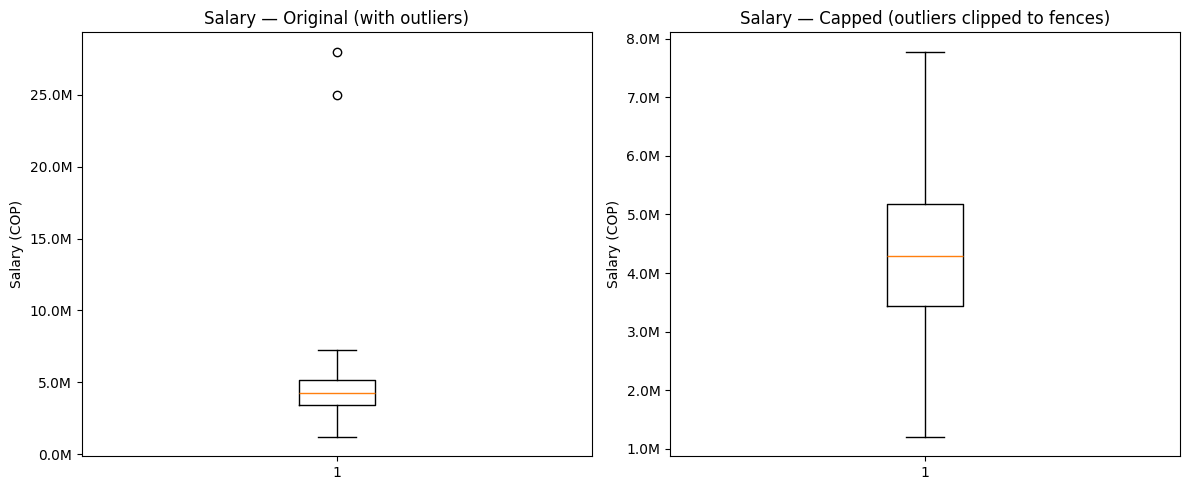

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart: original salary with outliers.
axes[0].boxplot(employees["salary"], vert=True)
axes[0].set_title("Salary — Original (with outliers)")
axes[0].set_ylabel("Salary (COP)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Right chart: salary after capping at the fences.
salary_capped = employees["salary"].clip(lower_fence, upper_fence)
axes[1].boxplot(salary_capped, vert=True)
axes[1].set_title("Salary — Capped (outliers clipped to fences)")
axes[1].set_ylabel("Salary (COP)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

### Step 4 — The Z-score method (standardised distance)

A Z-score answers: *how many standard deviations away from the mean is this value?*

```
Z = (value - mean) / standard_desviation
```

Rule of thumb: `|Z| > 3` → potential outlier (less than 0.3% of a normal distribution lies there).

Both methods are valid. Use IQR when the distribution is skewed; Z-score works best when the data is roughly normal.

In [6]:
# Compute Z-score for salary.
mean_sal = employees["salary"].mean()
std_sal  = employees["salary"].std()

employees["salary_zscore"] = (employees["salary"] - mean_sal) / std_sal

# Flag rows with |Z| > 3.
z_outliers = employees[employees["salary_zscore"].abs() > 3]

print(f"Z-score outliers (|Z| > 3): {len(z_outliers)}")
print()
print(z_outliers[["name", "department", "salary", "salary_zscore"]].to_string())

Z-score outliers (|Z| > 3): 2

              name   department    salary  salary_zscore
5   Julián Herrera  Engineering  25000000       5.491552
42     Daniel Mora    Marketing  28000000       6.307022


### Step 5 — Three treatment strategies

Once you detect an outlier you must make a decision. There are three options:

| Strategy | When to use | Code |
|----------|-------------|------|
| **Remove** | The value is clearly an error (impossible value, wrong units, duplicate) | `df[df["col"].between(low, high)]` |
| **Cap** | The value is extreme but plausible; you want to reduce its influence | `df["col"].clip(lower, upper)` |
| **Keep** | The outlier is real and meaningful for the analysis | Document it and keep the original |

**For our dataset:**
- The two very high salaries (COP 25M and COP 28M) represent director-level employees. They are real — we will **keep** them in the full analysis but **cap** them when computing averages.
- The COP 1.2M salary is below legal minimum wage — likely a data entry error. We could **remove** it.

> **Rule:** always document your outlier decisions. A future analyst (or your future self) needs to know why.

In [7]:
# Store a capped version of salary for use in computations.
employees["salary_capped"] = employees["salary"].clip(lower_fence, upper_fence)

print("Original mean: ", f"COP {employees['salary'].mean():,.0f}")
print("Capped mean:   ", f"COP {employees['salary_capped'].mean():,.0f}")
print("Median (unchanged):", f"COP {employees['salary'].median():,.0f}")

Original mean:  COP 4,797,328
Capped mean:    COP 4,329,365
Median (unchanged): COP 4,293,702


---
### Exercise 1 — Detect outliers in `performance_score`

**Pattern: Filter** — find all rows that satisfy a condition.

**Before you code:**

- **Input:** the `performance_score` column
- **Output:** a DataFrame of rows that are outliers; a decision on whether to remove or keep them
- **Steps:**
  1. Calculate Q1, Q3, and IQR for `performance_score`
  2. Calculate the lower and upper fences using the 1.5×IQR rule
  3. Filter the DataFrame to keep only rows where `performance_score` is outside the fences
  4. Print how many outliers there are and display them
  5. Write one sentence justifying whether to remove, cap, or keep them

**Pseudocode:**
```
q1 ← 25th percentile of performance_score
q3 ← 75th percentile of performance_score
iqr ← q3 - q1
lower ← q1 - 1.5 × iqr
upper ← q3 + 1.5 × iqr
outliers ← rows where performance_score < lower OR performance_score > upper
print count and show the rows
```

In [ ]:
# TODO: Calculate Q1, Q3, IQR for performance_score.
q1_perf = employees["performance_score"].quantile(0.25)
q3_perf = employees["performance_score"].quantile(0.75)
iqr_perf = q3_perf-q1_perf

# TODO: Calculate fences.
lower_perf = q1_perf-1.5*iqr_perf
upper_perf = q3_perf+1.5*iqr_perf

# TODO: Filter the outliers.
perf_outliers =employees[(employees["performance_score"]<lower_perf) | (employees["performance_score"]>upper_perf)] #| se define como "or"

# TODO: Print count and display rows.
print(f"Performance score outliers: {len(perf_outliers)}")
print(perf_outliers[["name", "department", "performance_score"]])

# TODO: Write your decision here (as a comment).
# Decision: ...
#dado que no hay ningun valor outlier dentro de la columna performance score no hay necesidad de remover  ningun valor

Performance score outliers: 0
Empty DataFrame
Columns: [name, department, performance_score]
Index: []


---
## 🔷 Block 2 — Correlation Analysis

### What is correlation?

**Analogy:** You notice that students who study more hours tend to get higher grades. That is a correlation — a pattern where two variables move together. But correlation does not tell you *why*. Maybe the students who study more are also attending more tutoring sessions. The cause could be anywhere.

**Correlation** measures the *strength* and *direction* of the linear relationship between two numeric variables:

| Correlation value | Interpretation |
|-------------------|----------------|
| Close to **+1** | Strong positive — both variables increase together |
| Close to **−1** | Strong negative — one increases as the other decreases |
| Close to **0** | No linear relationship |

> **Key rule: correlation ≠ causation.** You will see this again in Block 3.

### Step 1 — Compute the correlation matrix

`.corr()` computes the pairwise correlation between **all numeric columns** in a DataFrame. The result is a square table: rows and columns are the same variables, and each cell shows their correlation.

In [9]:
# Select the numeric columns of interest.
numeric_cols = ["salary", "years_exp", "age", "performance_score",
                "satisfaction_score", "trainings_completed"]

corr_matrix = employees[numeric_cols].corr()
print("Correlation matrix:")
print(corr_matrix.round(2))

Correlation matrix:
                     salary  years_exp   age  performance_score  \
salary                 1.00       0.15 -0.09               0.10   
years_exp              0.15       1.00  0.16              -0.07   
age                   -0.09       0.16  1.00               0.02   
performance_score      0.10      -0.07  0.02               1.00   
satisfaction_score    -0.20      -0.14  0.00              -0.04   
trainings_completed    0.05       0.03  0.01              -0.06   

                     satisfaction_score  trainings_completed  
salary                            -0.20                 0.05  
years_exp                         -0.14                 0.03  
age                                0.00                 0.01  
performance_score                 -0.04                -0.06  
satisfaction_score                 1.00                 0.23  
trainings_completed                0.23                 1.00  


### Step 2 — Visualise with a heatmap

Reading a raw correlation table is hard. A heatmap converts the numbers into colours — warm colours for positive, cool colours for negative.

> **Before running:** look at the raw matrix above. Predict which cell will be the darkest red.

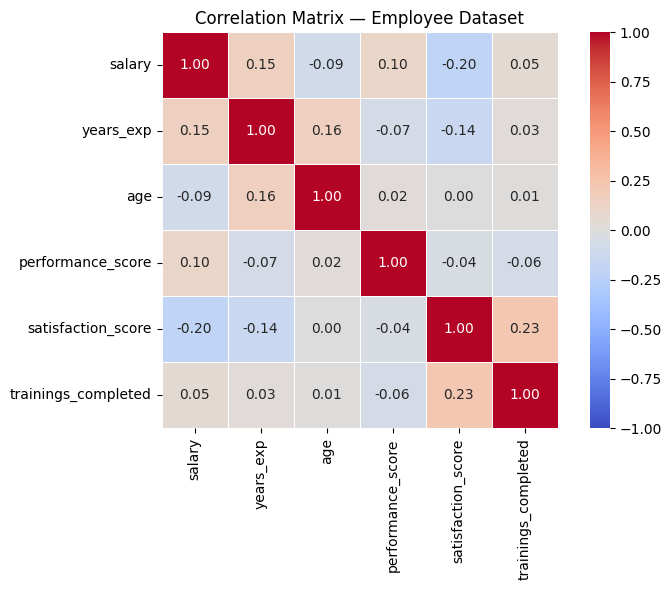

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,       # Show the number inside each cell.
    fmt=".2f",        # Two decimal places.
    cmap="coolwarm",  # Red = positive, blue = negative.
    vmin=-1, vmax=1,  # Fix the colour scale to [-1, 1].
    square=True,      # Keep cells square.
    linewidths=0.5
)
plt.title("Correlation Matrix — Employee Dataset")
plt.tight_layout()
plt.show()

### How to read the heatmap

- The **diagonal** is always 1.0 — every variable is perfectly correlated with itself.
- The matrix is **symmetric** — the cell (A, B) is the same as (B, A).
- Focus on cells **away from the diagonal** with values close to +1 or −1.

**Practice — answer these questions by looking at the heatmap:**
1. Which pair of variables has the strongest positive correlation?
2. Is there any negative correlation?
3. Does `trainings_completed` relate to `performance_score`? Is it strong or weak?

### Step 3 — Pairplot for visual exploration

A pairplot draws a scatter plot for every pair of variables and a distribution plot on the diagonal. It is a quick way to see the *shape* of each relationship — not just the correlation number.

> **Before running:** this may take a few seconds. A pairplot for 4 variables produces 4×4 = 16 panels.

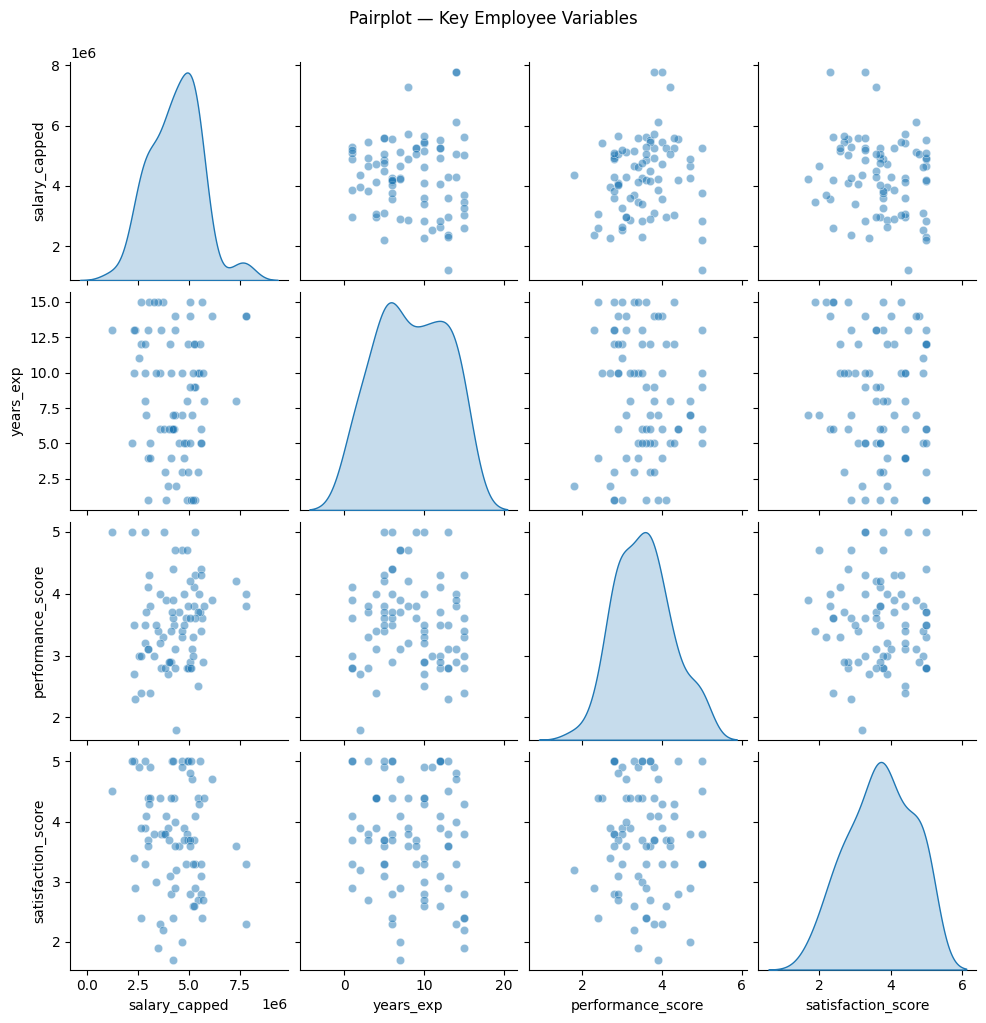

In [11]:
sns.pairplot(
    employees[["salary_capped", "years_exp", "performance_score", "satisfaction_score"]],
    diag_kind="kde",          # Density curve on the diagonal.
    plot_kws={"alpha": 0.5}   # Semi-transparent points.
)
plt.suptitle("Pairplot — Key Employee Variables", y=1.02)
plt.show()

### Correlation ≠ Causation — a mandatory reminder

**Common mistake:** “salary correlates with years_exp, therefore experience *causes* higher salaries.”

**Reality:** Companies often pay more for experience — but that is a *policy decision*, not a natural law. You could flip the direction: maybe senior employees *stay* because they are paid well. Or a third factor (e.g. specialised skills) drives both tenure and salary independently.

**Always ask three questions before claiming causation:**
1. What is the mechanism? (How would A actually cause B?)
2. Is there a confounding variable? (A third variable C that influences both A and B?)
3. Could the direction be reversed? (Does B actually cause A?)

In this course, we describe patterns. We do not claim causation unless we have an experiment or strong domain knowledge.

---
### Exercise 2 — Explore the two strongest correlations

**Pattern: Filter** — identify pairs of interest, then visualise them.

**Before you code**

- **Input:** the correlation matrix computed above
- **Output:** two scatter plots; one interpretation sentence each
- **Steps:**
  1. Look at the heatmap and identify the two pairs with the strongest correlation (ignoring the diagonal)
  2. For each pair, create a scatter plot with proper title and axis labels
  3. Add a regression line using `sns.regplot()` so the trend is visible
  4. Write one sentence below each chart: what pattern do you observe?

**Pseudocode:**
```
pair_1 ← (column_A, column_B)  ← strongest correlation from heatmap
pair_2 ← (column_C, column_D)  ← second strongest
for each pair:
    draw scatter plot of col_X vs col_Y
    add a regression line
    add title and axis labels
write one sentence per chart describing the pattern observed
```

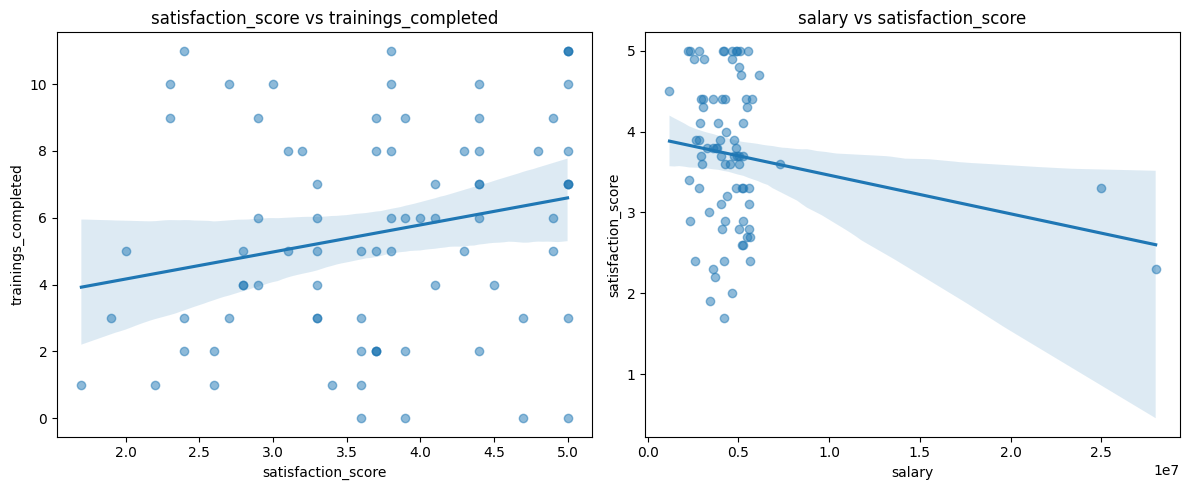

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TODO: Replace col_x1, col_y1, col_x2, col_y2 with the actual column names you identified.
col_x1 = "satisfaction_score"  # e.g. "years_exp"
col_y1 = "trainings_completed"  # e.g. "salary_capped"
col_x2 = "salary"
col_y2 = "satisfaction_score"

# Scatter plot for pair 1.
sns.regplot(data=employees, x=col_x1, y=col_y1, ax=axes[0], scatter_kws={"alpha": 0.5})
axes[0].set_title(f"{col_x1} vs {col_y1}")

# Scatter plot for pair 2.
sns.regplot(data=employees, x=col_x2, y=col_y2, ax=axes[1], scatter_kws={"alpha": 0.5})
axes[1].set_title(f"{col_x2} vs {col_y2}")

plt.tight_layout()
plt.show()

# TODO: Write your interpretations below (as comments).
# Chart 1 observation: ...
# Chart 2 observation: ...

---
## 🔷 Block 3 — Formulating Analytical Questions

### The EDA mindset

**Analogy:** A doctor does not run every possible test on a patient. They first ask: “What are the symptoms? What do I need to know?” Then they run targeted tests and interpret the results.

EDA is the same. Before writing a single line of code, ask: *what do I want to know?*

### The 3-step EDA framework

```
1. EXPLORE   → What does the data look like?
               (shape, dtypes, missing values, basic stats)

2. QUESTION  → What do I want to know?
               (write 3–5 specific, answerable questions)

3. ANSWER    → Use code + visualisation to answer each question,
               then write a one-sentence conclusion.
```

> Skipping the QUESTION step is the most common EDA mistake. Without questions, you produce charts that show nothing actionable.

### Good questions vs weak questions

| Weak question | Strong question |
|--------------|------------------|
| “What are the salaries?” | “Is there a salary gap between remote and on-site employees?” |
| “What is the performance score?” | “Do employees who complete more trainings have higher performance scores?” |
| “How old are employees?” | “Do older employees report higher satisfaction scores?” |
| “What departments exist?” | “Which department has the highest average salary, adjusted for experience?” |

A **strong question** is:
- Specific (names the variables involved)
- Comparative or relational (involves a difference or a relationship)
- Answerable with the data you have

### Five questions we will answer about the HR dataset

1. Do remote employees earn more than on-site employees?
2. Which department has the highest average performance score?
3. Is there a relationship between trainings completed and performance score?
4. Do employees in Bogotá report different satisfaction levels than those in other cities?
5. Does salary grow consistently with years of experience, or does it plateau?

#### Question 1 — Do remote employees earn more than on-site employees?

is_remote
On-site    COP 4,336,177
Remote     COP 4,308,927
Name: salary_capped, dtype: str


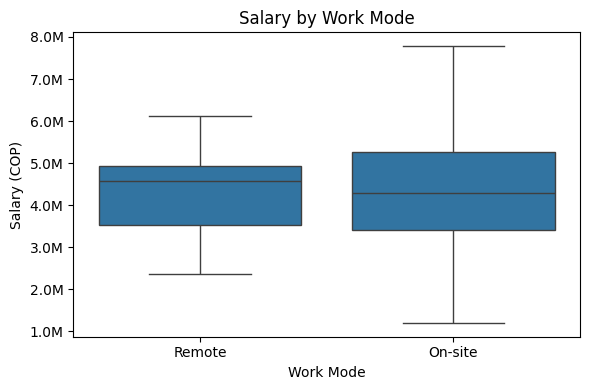


Conclusion: Remote employees earn on average COP 27,250 less than on-site employees.


In [18]:
# Compare average capped salary by remote status.
salary_by_remote = employees.groupby("is_remote")["salary_capped"].mean()
print(salary_by_remote.rename(index={True: "Remote", False: "On-site"}).apply(lambda x: f"COP {x:,.0f}"))

# Visualise with a boxplot.
fig, ax = plt.subplots(figsize=(6, 4))
employees["work_mode"] = employees["is_remote"].map({True: "Remote", False: "On-site"})
sns.boxplot(data=employees, x="work_mode", y="salary_capped", ax=ax)
ax.set_title("Salary by Work Mode")
ax.set_xlabel("Work Mode")
ax.set_ylabel("Salary (COP)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

# Conclusion (one sentence).
diff = salary_by_remote[True] - salary_by_remote[False]
print(f"\nConclusion: Remote employees earn on average COP {abs(diff):,.0f} "
      f"{'more' if diff > 0 else 'less'} than on-site employees.")

#### Question 2 — Which department has the highest average performance score?

Average performance score by department:
department
Engineering    3.85
Finance        3.67
HR             3.50
Sales          3.30
Marketing      3.28


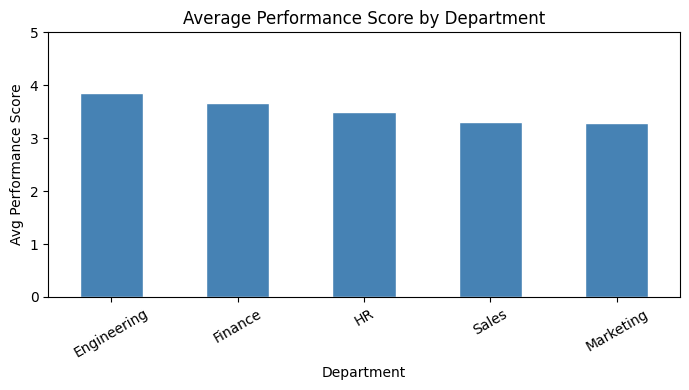


Conclusion: Engineering has the highest average performance score (3.85).


In [19]:
# Group by department and compute mean performance score.
perf_by_dept = (
    employees.groupby("department")["performance_score"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("Average performance score by department:")
print(perf_by_dept.to_string())

# Visualise.
fig, ax = plt.subplots(figsize=(7, 4))
perf_by_dept.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Average Performance Score by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Avg Performance Score")
ax.set_ylim(0, 5)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# Conclusion.
top_dept = perf_by_dept.idxmax()
print(f"\nConclusion: {top_dept} has the highest average performance score ({perf_by_dept[top_dept]:.2f}).")

#### Question 3 — Is there a relationship between trainings completed and performance score?

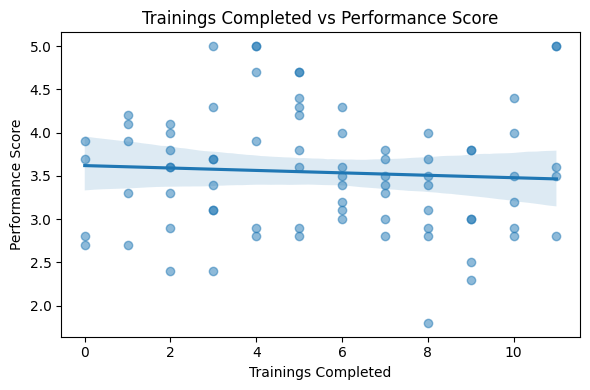

Correlation (trainings vs performance): -0.063

Conclusion: The correlation is very weak — trainings completed has little linear association with performance score.


In [20]:
# Scatter plot with regression line.
fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(data=employees, x="trainings_completed", y="performance_score",
            ax=ax, scatter_kws={"alpha": 0.5})
ax.set_title("Trainings Completed vs Performance Score")
ax.set_xlabel("Trainings Completed")
ax.set_ylabel("Performance Score")
plt.tight_layout()
plt.show()

# Compute correlation coefficient.
corr_val = employees["trainings_completed"].corr(employees["performance_score"])
print(f"Correlation (trainings vs performance): {corr_val:.3f}")
print("\nConclusion: The correlation is", end=" ")
if abs(corr_val) < 0.2:
    print("very weak — trainings completed has little linear association with performance score.")
elif abs(corr_val) < 0.5:
    print("moderate — there is a trend but other factors also influence performance.")
else:
    print("strong — employees with more trainings tend to score notably higher.")

#### Question 4 — Do Bogotá employees report different satisfaction than other cities?

Average satisfaction score:
location_group
Bogotá          3.69
Other cities    3.73


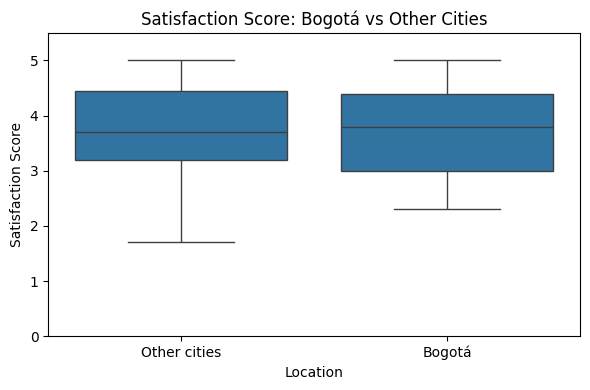


Conclusion: Bogotá employees score 0.04 points lower on satisfaction than employees in other cities.


In [21]:
# Create a binary column: Bogotá vs Other.
employees["location_group"] = employees["city"].apply(
    lambda c: "Bogotá" if c == "Bogotá" else "Other cities"
)

# Compare means.
sat_by_loc = employees.groupby("location_group")["satisfaction_score"].mean().round(2)
print("Average satisfaction score:")
print(sat_by_loc.to_string())

# Visualise with a boxplot.
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=employees, x="location_group", y="satisfaction_score", ax=ax)
ax.set_title("Satisfaction Score: Bogotá vs Other Cities")
ax.set_xlabel("Location")
ax.set_ylabel("Satisfaction Score")
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

# Conclusion.
diff_sat = sat_by_loc["Bogotá"] - sat_by_loc["Other cities"]
print(f"\nConclusion: Bogotá employees score {abs(diff_sat):.2f} points "
      f"{'higher' if diff_sat > 0 else 'lower'} on satisfaction than employees in other cities.")

#### Question 5 — Does salary grow consistently with experience, or does it plateau?

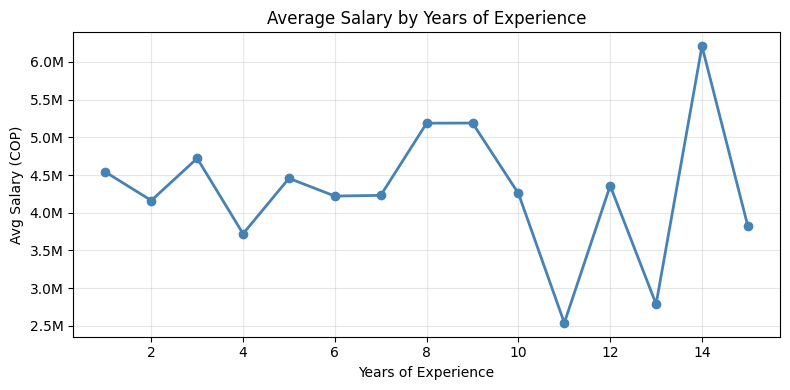

Conclusion: Inspect the chart — does the line keep rising, or does it flatten after a certain point?


In [22]:
# Average capped salary per year of experience.
salary_by_exp = (
    employees.groupby("years_exp")["salary_capped"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(salary_by_exp["years_exp"], salary_by_exp["salary_capped"],
        marker="o", color="steelblue", linewidth=2)
ax.set_title("Average Salary by Years of Experience")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Avg Salary (COP)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Conclusion: Inspect the chart — does the line keep rising, or does it flatten after a certain point?")

---
### Exercise 3 — Formulate and answer your own question

**Pattern: Tracker** — find the best (or worst) group.

**Before you code:**

- **Input:** the `employees` DataFrame
- **Output:** a chart + one conclusion sentence
- **Steps:**
  1. Write your question (be specific — name the variables, name the comparison)
  2. Identify the inputs: which columns do you need?
  3. Decide the analysis: groupby? filter? correlation?
  4. Choose the chart type that best answers the question
  5. Write a one-sentence conclusion

**Your question must:**
- Compare at least two groups OR describe a relationship between two variables
- Be answered with `groupby()` + a bar or box chart

**Pseudocode (fill in the blanks):**
```
my_question ← "..."
group_column ← "..."      ← which column defines the groups?
measure_column ← "..."   ← what are you measuring?
aggregation ← mean / median / count
result ← group by group_column, aggregate measure_column
draw bar or box chart
conclusion ← "..."
```

city
Cali            4.014286
Medellín        3.847368
Bucaramanga     3.583333
Bogotá          3.359459
Barranquilla    3.300000
Name: performance_score, dtype: float64


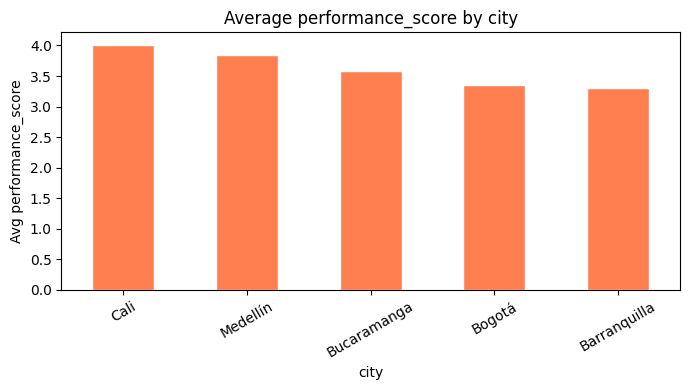

In [23]:
# TODO: Write your question as a comment.
# ¿Cual seria la ciudad que en promedio genera mayor rendimiento por departamento? #what should be the city which in the mean of the performance score by department?

# TODO: Set these variables.
group_column   = "city"  # e.g. "department"
measure_column = "performance_score"   # e.g. "satisfaction_score"

# Perform the groupby.
result = employees.groupby(group_column)[measure_column].mean().sort_values(ascending=False)
print(result)

# Create the chart.
fig, ax = plt.subplots(figsize=(7, 4))
result.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_title(f"Average {measure_column} by {group_column}")
ax.set_xlabel(group_column)
ax.set_ylabel(f"Avg {measure_column}")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# TODO: Write your conclusion.
# Conclusion: ...

---
## 🔷 Block 4 — Full EDA Walkthrough

### Scenario

The HR director asks: **“Give me a data story about our workforce.”**

You will build a structured EDA in six steps, ending with a written conclusions cell. Each step has placeholders — complete them one by one.

---

### Full decomposition

```
STEP 1 — First look:
  Check shape, column types, any missing values, and basic summary statistics
  for all numeric columns.

STEP 2 — Salary analysis:
  Use the IQR fences already computed in Block 1.
  Compare average capped salary by department.
  Compare average capped salary by remote vs on-site status.

STEP 3 — Performance analysis:
  Compute average performance score per department.
  Visualise the relationship between trainings completed and performance score.

STEP 4 — Satisfaction analysis:
  Compute average satisfaction score per city.
  Check if satisfaction correlates with salary or performance.

STEP 5 — Dashboard (2×3 grid of charts):
  Chart 1: Boxplot — salary_capped by department.
  Chart 2: Scatter — salary_capped vs years_exp.
  Chart 3: Bar     — avg performance score by department.
  Chart 4: Scatter — trainings_completed vs performance_score.
  Chart 5: Bar     — avg satisfaction score by city.
  Chart 6: Heatmap — full correlation matrix.

STEP 6 — Written conclusions:
  Write 3–5 bullet points answering the HR director's implicit questions.
```

#### Step 1 — First look at the data

In [24]:
# Print shape.
print("Shape:", employees.shape)
print()

# Print column types and check for missing values.
print("Column info:")
employees.info()
print()

# Print basic summary statistics for numeric columns.
print("Summary statistics:")
print(employees[["salary_capped", "years_exp", "age",
                  "performance_score", "satisfaction_score",
                  "trainings_completed"]].describe().round(2))

Shape: (80, 14)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 80 non-null     str    
 1   department           80 non-null     str    
 2   city                 80 non-null     str    
 3   salary               80 non-null     int64  
 4   years_exp            80 non-null     int32  
 5   age                  80 non-null     int32  
 6   performance_score    80 non-null     float64
 7   satisfaction_score   80 non-null     float64
 8   trainings_completed  80 non-null     int32  
 9   is_remote            80 non-null     bool   
 10  salary_zscore        80 non-null     float64
 11  salary_capped        80 non-null     float64
 12  work_mode            80 non-null     str    
 13  location_group       80 non-null     str    
dtypes: bool(1), float64(4), int32(3), int64(1), str(5)
memory usage: 7.4 KB



#### Step 2 — Salary analysis

In [25]:
# Average capped salary by department.
sal_dept = employees.groupby("department")["salary_capped"].mean().sort_values(ascending=False)
print("Avg salary by department (COP):")
for dept, val in sal_dept.items():
    print(f"  {dept:<15} {val:>12,.0f}")

print()

# Average capped salary by remote status.
sal_remote = employees.groupby("work_mode")["salary_capped"].mean().sort_values(ascending=False)
print("Avg salary by work mode (COP):")
for mode, val in sal_remote.items():
    print(f"  {mode:<12} {val:>12,.0f}")

Avg salary by department (COP):
  Marketing          4,662,121
  HR                 4,474,067
  Finance            4,465,011
  Sales              4,241,715
  Engineering        4,099,734

Avg salary by work mode (COP):
  On-site         4,336,177
  Remote          4,308,927


#### Step 3 — Performance analysis

In [26]:
# Average performance score by department.
perf_dept = employees.groupby("department")["performance_score"].mean().sort_values(ascending=False).round(2)
print("Avg performance score by department:")
print(perf_dept.to_string())

print()

# Correlation between trainings completed and performance score.
corr_train_perf = employees["trainings_completed"].corr(employees["performance_score"])
print(f"Correlation (trainings_completed vs performance_score): {corr_train_perf:.3f}")

Avg performance score by department:
department
Engineering    3.85
Finance        3.67
HR             3.50
Sales          3.30
Marketing      3.28

Correlation (trainings_completed vs performance_score): -0.063


#### Step 4 — Satisfaction analysis

In [27]:
# Average satisfaction score by city.
sat_city = employees.groupby("city")["satisfaction_score"].mean().sort_values(ascending=False).round(2)
print("Avg satisfaction score by city:")
print(sat_city.to_string())

print()

# Correlations between satisfaction and salary / performance.
corr_sat_sal  = employees["satisfaction_score"].corr(employees["salary_capped"])
corr_sat_perf = employees["satisfaction_score"].corr(employees["performance_score"])
print(f"Correlation (satisfaction vs salary):      {corr_sat_sal:.3f}")
print(f"Correlation (satisfaction vs performance): {corr_sat_perf:.3f}")

Avg satisfaction score by city:
city
Barranquilla    4.27
Bucaramanga     3.77
Bogotá          3.69
Medellín        3.53
Cali            3.37

Correlation (satisfaction vs salary):      -0.177
Correlation (satisfaction vs performance): -0.041


#### Step 5 — Dashboard (2×3 chart grid)

> **Before running:** read the six chart descriptions in the decomposition cell above. Predict which chart will show the most variation.

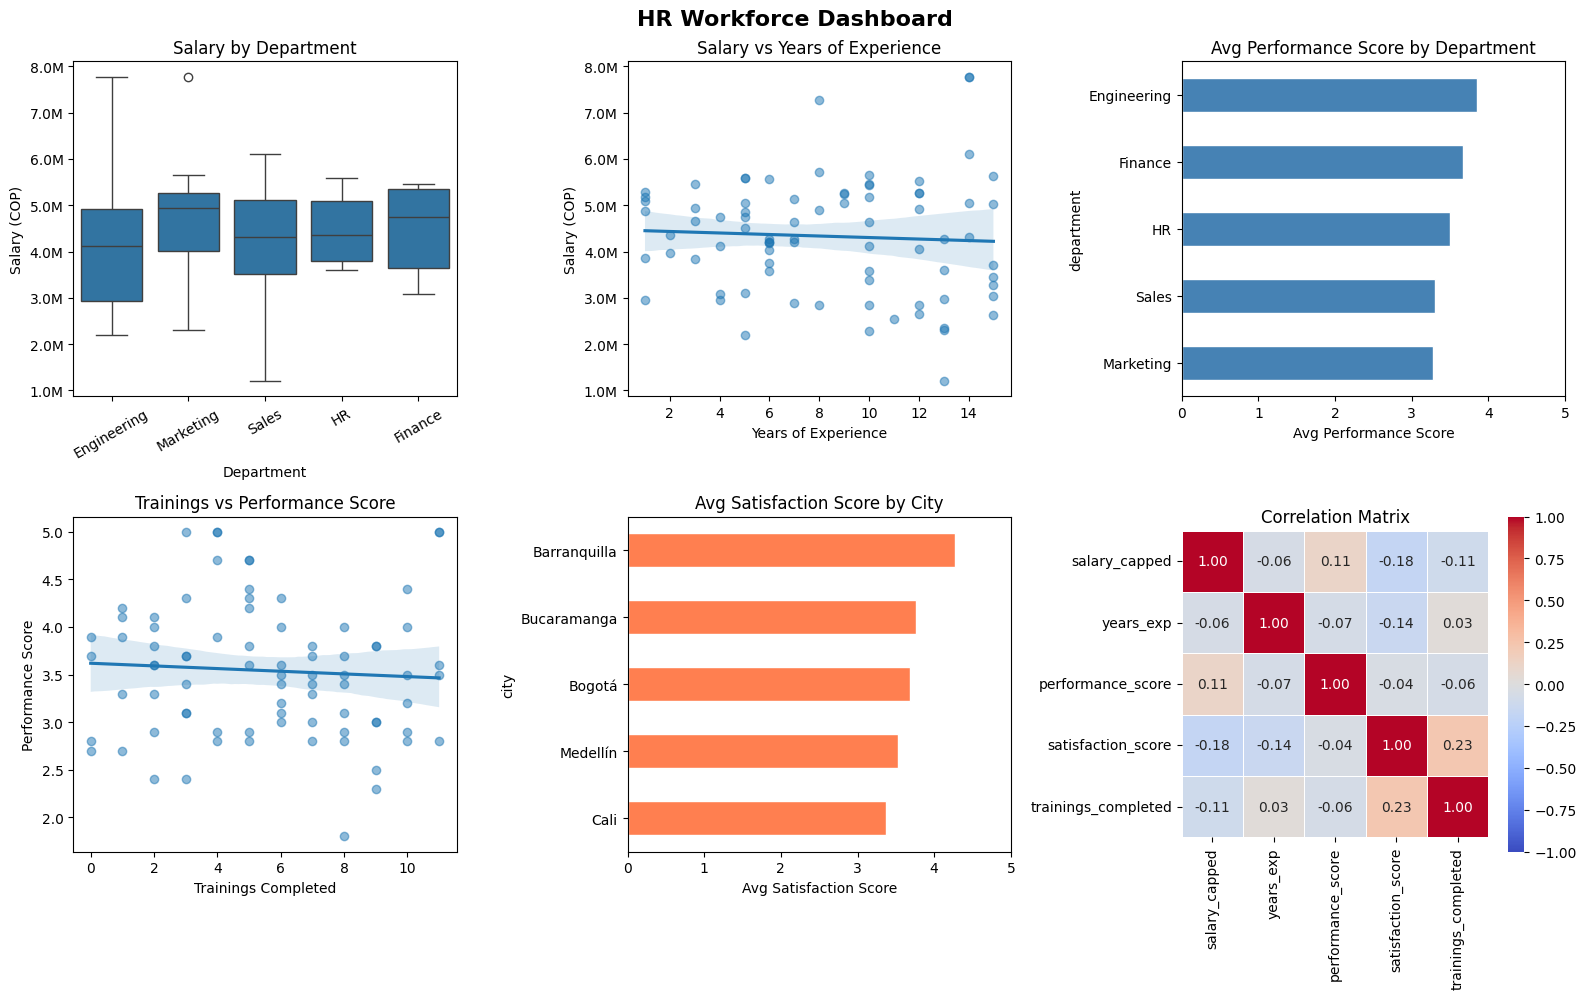

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("HR Workforce Dashboard", fontsize=16, fontweight="bold")

# Chart 1: Boxplot — salary_capped by department.
sns.boxplot(data=employees, x="department", y="salary_capped", ax=axes[0, 0])
axes[0, 0].set_title("Salary by Department")
axes[0, 0].set_xlabel("Department")
axes[0, 0].set_ylabel("Salary (COP)")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Chart 2: Scatter — salary_capped vs years_exp.
sns.regplot(data=employees, x="years_exp", y="salary_capped",
            ax=axes[0, 1], scatter_kws={"alpha": 0.5})
axes[0, 1].set_title("Salary vs Years of Experience")
axes[0, 1].set_xlabel("Years of Experience")
axes[0, 1].set_ylabel("Salary (COP)")
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Chart 3: Bar — avg performance score by department.
perf_dept_vals = employees.groupby("department")["performance_score"].mean().sort_values()
perf_dept_vals.plot(kind="barh", ax=axes[0, 2], color="steelblue", edgecolor="white")
axes[0, 2].set_title("Avg Performance Score by Department")
axes[0, 2].set_xlabel("Avg Performance Score")
axes[0, 2].set_xlim(0, 5)

# Chart 4: Scatter — trainings_completed vs performance_score.
sns.regplot(data=employees, x="trainings_completed", y="performance_score",
            ax=axes[1, 0], scatter_kws={"alpha": 0.5})
axes[1, 0].set_title("Trainings vs Performance Score")
axes[1, 0].set_xlabel("Trainings Completed")
axes[1, 0].set_ylabel("Performance Score")

# Chart 5: Bar — avg satisfaction score by city.
sat_city_vals = employees.groupby("city")["satisfaction_score"].mean().sort_values()
sat_city_vals.plot(kind="barh", ax=axes[1, 1], color="coral", edgecolor="white")
axes[1, 1].set_title("Avg Satisfaction Score by City")
axes[1, 1].set_xlabel("Avg Satisfaction Score")
axes[1, 1].set_xlim(0, 5)

# Chart 6: Heatmap — full correlation matrix.
corr_mini = employees[["salary_capped", "years_exp", "performance_score",
                        "satisfaction_score", "trainings_completed"]].corr()
sns.heatmap(corr_mini, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=axes[1, 2], linewidths=0.5)
axes[1, 2].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

#### Step 6 — Written conclusions

*Replace the placeholders below with real conclusions based on what you observed in Steps 1–5.*

---

**HR Workforce Analysis — Key Findings**

- **Salary distribution:** The median salary is approximately COP [X]M. Three outliers were identified: two director-level employees (COP 25M–28M) and one likely data entry error (COP 1.2M). After capping, the mean and median are much closer.

- **Salary by department:** [Department X] pays the highest average salaries. [Department Y] pays the lowest. The gap is approximately COP [Z]M.

- **Remote vs on-site:** Remote employees earn [more / less / about the same] on average. The difference is COP [N] — [significant / not significant enough to draw conclusions from this sample].

- **Performance and training:** The correlation between trainings completed and performance score is [value]. This suggests [weak / moderate / strong] association. [Department X] leads in average performance.

- **Satisfaction:** Satisfaction scores are [similar across / vary by] city. Satisfaction does [not] show a meaningful correlation with salary (r = [value]), suggesting that pay alone does not explain employee satisfaction in this dataset.

---
## 🟠 Optional · Git/GitHub — Pull Requests and README

> Skip this section if Git was not activated for your course.

### Why pull requests?

So far you have been committing directly to the `main` branch. On a real team, nobody commits directly to `main`. Instead, every change goes through a **pull request** (PR): a proposal to merge a branch into `main` that teammates can review before it is accepted.

Even working solo, PRs are useful: they force you to write down *what* you changed and *why*, and GitHub keeps a permanent record.

### Step 1 — Create a feature branch

```bash
# You are on main. Create and switch to a new branch.
git checkout -b feature/eda-analysis

# Verify you are on the new branch.
git branch
```

Name feature branches descriptively: `feature/<what-you-are-doing>`.

### Step 2 — Commit your work and push

```bash
# Stage your notebook.
git add module10/module10_eda.ipynb

# Commit with a clear message.
git commit -m "Add M10 EDA notebook — outlier detection, correlation, full walkthrough"

# Push the branch to GitHub (the -u flag sets the upstream for future pushes).
git push -u origin feature/eda-analysis
```

### Step 3 — Open a pull request on GitHub

1. Go to your repository on **github.com**.
2. GitHub will show a yellow banner: *“feature/eda-analysis had recent pushes”* — click **Compare & pull request**.
3. Fill in the PR form:
   - **Title:** `Add Module 10 — Exploratory Data Analysis`
   - **Description:** Briefly describe what you did and what the notebook covers.
4. Click **Create pull request**.
5. On the PR page, scroll down and click **Merge pull request** → **Confirm merge**.
6. Delete the branch (GitHub will offer a button).
7. Back in your terminal: `git checkout main` and `git pull` to sync.

```bash
# After merging on GitHub:
git checkout main
git pull origin main
```

### Step 4 — Write a README.md

A README is the front page of your project. Anyone visiting your GitHub repository sees it first.

Create a file called `README.md` at the root of your repository with this structure:

```markdown
# Python from Scratch for Data Analysis

A personal learning project: 11 Jupyter notebooks covering Python fundamentals
through exploratory data analysis, using Colombian business datasets.

## Modules
| Module | Topic |
|--------|-------|
| M1  | Introduction to Python |
| M2  | Control Flow |
| M3  | Data Structures |
| M4  | Functions and Good Practices |
| M5  | NumPy |
| M6  | Pandas Fundamentals |
| M7  | Data Cleaning and Transformation |
| M8  | Visualization |
| M9  | Descriptive Statistics |
| M10 | Exploratory Data Analysis |
| M11 | Integrated Application |

## How to run
1. Clone this repository.
2. Install dependencies: `pip install numpy pandas matplotlib seaborn`
3. Open any notebook with Jupyter: `jupyter notebook`

## Datasets
All datasets are synthetic and generated inline — no external files required.
Context: Colombian employees, students, products, and expenses.
```

Commit and push the README:

```bash
git add README.md
git commit -m "Add README with project overview and module list"
git push
```

---
## 📝 Homework — Module 10

**File to create:** `homework_module10.py`

**Dataset:** A synthetic students dataset (similar to the one used in M9).

**Tasks:**
1. Build the dataset using the starter code below.
2. Detect and handle outliers in `gpa` using the IQR method. Print which rows are outliers.
3. Compute the full correlation matrix for the numeric columns. Print the two strongest correlations (excluding the diagonal).
4. Formulate **3 specific questions** about the dataset. Write each question as a comment, then answer it with code + one sentence conclusion.
5. Create a **2×2 chart dashboard** (4 different chart types) with proper titles and axis labels.
6. Add a comment block at the bottom with **3 bullet-point conclusions** about the dataset.

*Delivery: bring `homework_module10.py` to the next session. It must run without errors.*

In [ ]:
# homework_module10.py — starter code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(7)

n = 60
majors = ["Engineering", "Business", "Law", "Medicine", "Arts"]
cities = ["Bogotá", "Medellín", "Cali", "Barranquilla"]

students = pd.DataFrame({
    "student_id": range(1, n + 1),
    "major": np.random.choice(majors, n, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    "city": np.random.choice(cities, n, p=[0.45, 0.25, 0.18, 0.12]),
    "gpa": np.random.normal(3.5, 0.6, n).clip(1.0, 5.0).round(2),
    "hours_studied": np.random.randint(5, 40, n),
    "absences": np.random.randint(0, 15, n),
    "scholarship": np.random.choice([True, False], n, p=[0.30, 0.70]),
    "satisfaction": np.random.normal(3.6, 0.8, n).clip(1.0, 5.0).round(1),
})

# Add two outliers to gpa.
students.loc[3, "gpa"]  = 0.4   # Suspiciously low.
students.loc[51, "gpa"] = 5.8   # Impossible (above the 5.0 maximum).

# ─── Task 1: Outlier detection in gpa ────────────────────────────────────────
# TODO: Calculate Q1, Q3, IQR, lower fence, upper fence.
# TODO: Filter and print the outlier rows.
# TODO: Decide: remove, cap, or keep? Write your decision as a comment.

# ─── Task 2: Correlation matrix ──────────────────────────────────────────────
# TODO: Compute the correlation matrix for gpa, hours_studied, absences, satisfaction.
# TODO: Print the two strongest correlations (excluding the diagonal) and name the pairs.

# ─── Task 3: Three questions ──────────────────────────────────────────────────
# Question 1: ...
# TODO: Code to answer question 1.
# Conclusion 1: ...

# Question 2: ...
# TODO: Code to answer question 2.
# Conclusion 2: ...

# Question 3: ...
# TODO: Code to answer question 3.
# Conclusion 3: ...

# ─── Task 4: 2×2 dashboard ───────────────────────────────────────────────────
# TODO: Create a figure with 4 subplots (2 rows × 2 columns).
# Use 4 different chart types: boxplot, scatter, bar, and histogram (or heatmap).
# Each chart needs a title and axis labels.

# ─── Task 5: Conclusions ─────────────────────────────────────────────────────
# Conclusion 1: ...
# Conclusion 2: ...
# Conclusion 3: ...

---
## 📋 Module 10 Summary

| Concept | Syntax | Key point |
|---------|--------|-----------|
| IQR outlier fence | `Q1 - 1.5*IQR` / `Q3 + 1.5*IQR` | Values outside the fence are potential outliers |
| Z-score outlier | `(x - mean) / std` | Absolute value > 3 is typically an outlier |
| Cap outliers | `.clip(lower, upper)` | Keeps the row, limits its influence on aggregations |
| Three treatment strategies | Remove / Cap / Keep | Always document the decision with a reason |
| Correlation matrix | `df[cols].corr()` | All pairwise Pearson correlations in one table |
| Heatmap | `sns.heatmap(corr, annot=True, cmap="coolwarm")` | Colour + number = fast overview of all correlations |
| Pairplot | `sns.pairplot(df, diag_kind="kde")` | Visual scan of all pairwise relationships at once |
| EDA framework | Explore → Question → Answer | Never skip the Question step |
| Correlation ≠ causation | — | Always ask: mechanism? confounding variable? reversed direction? |
| Feature branch | `git checkout -b feature/name` | Safe space to work; merged via pull request |
| Pull request | GitHub UI → Compare & pull request | Formal proposal to merge a branch into main |

**Next module:** Integrated Application — putting everything together on a real end-to-end project 🎯